## This is a sample Machine Learning project that exemplifies how to proceed Count Data Regression Analysis, using Python, Pandas, NumPy, SciPy, Statsmodels, Statstests, Tabulate, Scikit-learn, Matplotlib, Seaborn and Plotly, along with Anaconda managed environments

In [1]:
!pip install --upgrade statstests # gotta install statstests through pip - not available at conda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from math import exp, factorial
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP,ZeroInflatedPoisson
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson
from statsmodels.iolib.summary2 import summary_col
from statstests.tests import overdisp
from scipy import stats
from scipy.stats import norm
from scipy.interpolate import interp1d
from tabulate import tabulate
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import os
if os.getenv("GITHUB_ACTIONS") == "true":
    pio.renderers.default = "png"
else:
    pio.renderers.default='colab'
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

- the formulas shown at this notebook have been taken from the following reference:

    FÁVERO, L. P.; BELFIORE, P. Manual de Análise de Dados: Estatística e Machine Learning com Excel®, SPSS®, Stata®, R® e Python®. 2ª edição, 1288 p. Brasil: ccGEN LTC, 2024.
    
    Available in Brazil at:
    
    https://www.amazon.com.br/Manual-An-C3-A1lise-Dados-Estat-C3-ADstica-Learning-dp-8595159920/dp/8595159920

## Use Case Scenario and Data - Violations = f(staff, post, corruption). Zero-Inflated Poisson Regression (ZIP) - Count Data.

This is a simple use-case for Generalized Linear Models (GLMs) of type Zero-Inflated Poisson Regression (ZIP) for Count Data or Rate Data (PR). For other Count Data regression types (e.g. PR, NB, ZINB), see other examples at this same project directory. Here, we reuse the same dataset already used at the Poisson Regression (PR), and this dataset is actually being reused in all four use-cases at this directory. So, if you wanna read more about it, or about Regression Analysis for Count Data fundamentals, check out the first project, about Poisson Regression (PR) [here](./regression-analysis-count-data-poisson-violations.ipynb).

In the specific case of a Zero-Inflated Poisson Regression (ZIP), we have a combination of a binary model (Bernoulli) with a Count Data model (Poisson). The proof of statistic zero inflation at the model is done through the Vuong test (1989). If we actually have zero-inflation, the Yi count is generated by 2 components, a dicotomic binary component, that always generates structural zeros as a count, with probability p, and a Poisson count component, that generates any non-negative count, including, in part, 0, by chance, with probability (1-p). The dicotomic component always generates zero because the event even had a chance to occur, for ex., a person never got sick, so he never had a chance of deciding to go to hospital, during a certain period of time. The Poisson count component, on the other hand, works as a normal Poisson, but, in the case of 0, the count is taken by chance and not as a fixed value, for ex., a person got sick and might have decided or not to go to hospital. On the first case, the event never would have happened, while, on the second case, the event could have happened, but eventually didn't, by chance. For non-zero Yi values, normal Poisson applies. 

We combine the two components by including them into the PMF formula of ZIP: the first component (always 0) with p probability, the Poisson component (including 0 by chance cases) with (1-p) probability. This p is the probability from logistic regression, calculated based on the regressed logit. So, we have actually two regressions: one is the regression of the logit on its predictors (and params), which will define the dicotomic p and (1-p) - this p is the Plogit; the other regression is the normal Poisson lambdai, which regresses on its predictors, and generates the probability regarding the second component of the formula (see formulas at the picture below).

![./zip.png](./zip.png)

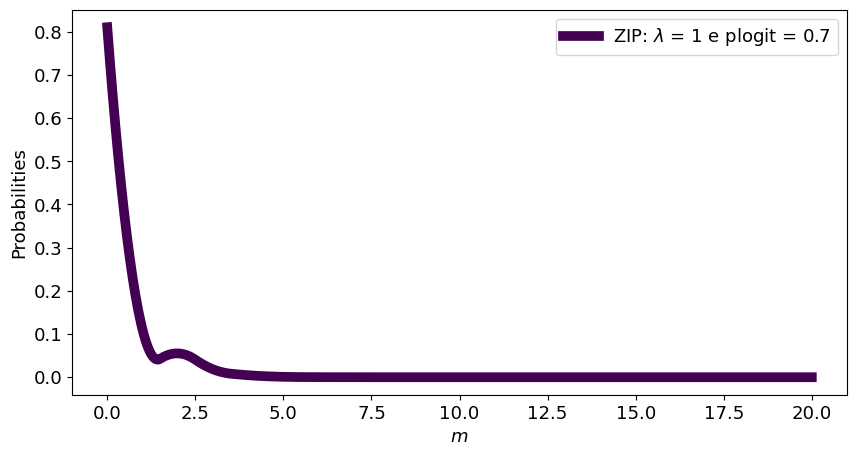

In [2]:
# creating a sample Probability Mass Function (PMF) of Zero-Inflated Poisson (ZIP) distribution
# In our use case, each observation will have its own lambdai and plogit, therefore its own p, (1-p) and PMFs for the
# dicotomic logist part of P(Yi=m=0) as for the Poisson part of the same probability, as well as for the probabilities of
# P(Yi=m>0). The PMF below is just for didactic purposes and has nothing to do with our dataset or any ZIP model.

# ZIP PMF for lambda = 1 and plogit = 0.7
def zip_lambda1_plogit07(m):
    lmbda = 1
    plogit = 0.7
    if m == 0:
        return (plogit) + ((1 - plogit) * exp(-lmbda))
    else:
        return (1 - plogit) * ((exp(-lmbda) * lmbda ** m) / factorial(m))

# calculating and storing the ZIP probabilities for m from 0 to 20:
m = np.arange(0,21)
zip_lambda1_plogit07 = [zip_lambda1_plogit07(i) for i in m]
zip_df = pd.DataFrame({'m':m,
                       'zip_lambda1_plogit07':zip_lambda1_plogit07})
zip_df

# Plotting ZIP distribution
def smooth_line_plot(x,y):
    x_new = np.linspace(x.min(), x.max(),500)
    f = interp1d(x, y, kind='quadratic')
    y_smooth=f(x_new)
    return x_new, y_smooth
x_new, zip_lambda1_plogit07 = smooth_line_plot(zip_df.m,
                                               zip_df.zip_lambda1_plogit07)

plt.figure(figsize=(10,5))
plt.plot(x_new,zip_lambda1_plogit07, linewidth=7, color="#440154FF")
plt.xlabel('m', fontsize=13, style='italic')
plt.ylabel('Probabilities', fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend([r'ZIP: $\lambda$ = 1 e plogit = 0.7'],
           fontsize=13)
plt.show()

# Observe below the high probability for Yi=m=0, typical of ZIP Counts, part of it due to the dicotomic component, the 
# other part from the Poisson component, while, for the rest of m values (m>0), it's all due to the Poisson component.

In [3]:
# Now, getting back to our dataset and estimating the ZIP model

corruption_df = pd.read_csv('corruption.csv', delimiter=',')

# defining the dependent variable
y = corruption_df['violations']

# defining predictors for the Poisson Count part of the PMF
x1 = corruption_df[['staff','post','corruption']]
X1 = sm.add_constant(x1)

# manual Dummization of 'post' variable (this api won't do it automatically)
X1 = pd.get_dummies(X1, columns=['post'], dtype=int, drop_first=True)

# defining predictors for the dicotomic logit (inflate) part of the PMF
x2 = corruption_df[['corruption']]
X2 = sm.add_constant(x2)

# 'exog_infl' corresponds to the predictive variables that are part of the dicotomic logit (inflate) component of PMF
zip_model = sm.ZeroInflatedPoisson(y, X1, exog_infl=X2,
                                    inflation='logit').fit()
zip_model.summary()

Optimization terminated successfully.
         Current function value: 5.977545
         Iterations: 22
         Function evaluations: 27
         Gradient evaluations: 27


<class 'statsmodels.iolib.summary.Summary'>
"""
                     ZeroInflatedPoisson Regression Results                    
===============================================================================
Dep. Variable:              violations   No. Observations:                  298
Model:             ZeroInflatedPoisson   Df Residuals:                      294
Method:                            MLE   Df Model:                            3
Date:                 Sun, 19 Apr 2026   Pseudo R-squ.:                  0.1975
Time:                         03:02:02   Log-Likelihood:                -1781.3
converged:                        True   LL-Null:                       -2219.8
Covariance Type:             nonrobust   LLR p-value:                8.828e-190
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
inflate_const         -1.6116      0.240     -6.714      0.000      -2.082      -1.141
inflate_corruption    -0.9523      0.195     -4.875      0.000      -1.335      -0.569
const                  2.4889      0.032     78.990      0.000       2.427       2.551
staff                  0.0200      0.001     16.154      0.000       0.018       0.022
corruption             0.0937      0.030      3.127      0.002       0.035       0.152
post_yes              -4.2879      0.201    -21.291      0.000      -4.683      -3.893
======================================================================================
"""

In [4]:
# observe above we have the regression coefficients (params) for the both regressions: the inflate_ params are 
# the alfa (or beta0) and beta1 of the logit regression - for which we have only one predictive variable (corruption) 
# - thus only one beta1; and the other params, which are the ones which the Poisson lambdai regresses on. Based on 
# these model coefficients and on each observation predictor's values, we can calculate each observation logit (and 
# plogit) and lambdai, and therefore the whole PMF distribution per observation.

In [5]:
# redefining classic Poisson equivalent model for comparing with ZIP model at Vuong zero-inflation test
poisson_model = sm.Poisson.from_formula('violations ~ staff + post + corruption',
                                         data=corruption_df).fit()

Optimization terminated successfully.
         Current function value: 6.952328
         Iterations 9


In [6]:
# Vuong test, for statistically confirming zero inflation at Count Data / Rate models

def vuong_test(m1, m2):
    if m1.__class__.__name__ == "GLMResultsWrapper":
        glm_family = modelo_poisson.model.family
        X = pd.DataFrame(data=m1.model.exog, columns=m1.model.exog_names)
        y = pd.Series(m1.model.endog, name=m1.model.endog_names)
        if glm_family.__class__.__name__ == "Poisson":
            m1 = Poisson(endog=y, exog=X).fit()
        if glm_family.__class__.__name__ == "NegativeBinomial":
            m1 = NegativeBinomial(endog=y, exog=X, loglike_method='nb2').fit()
    supported_models = [ZeroInflatedPoisson,ZeroInflatedNegativeBinomialP,Poisson,NegativeBinomial]
    if type(m1.model) not in supported_models:
        raise ValueError(f"Model type not supported for first parameter. List of supported models: (ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP, Poisson, NegativeBinomial) from statsmodels discrete collection.")
    if type(m2.model) not in supported_models:
        raise ValueError(f"Model type not supported for second parameter. List of supported models: (ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP, Poisson, NegativeBinomial) from statsmodels discrete collection.")
    
    # dependent variables extraction from the models
    m1_y = m1.model.endog
    m2_y = m2.model.endog
    m1_n = len(m1_y)
    m2_n = len(m2_y)
    if m1_n == 0 or m2_n == 0:
        raise ValueError("Could not extract dependent variables from models.")
    if m1_n != m2_n:
        raise ValueError("Models appear to have different numbers of observations.\n"
                         f"Model 1 has {m1_n} observations.\n"
                         f"Model 2 has {m2_n} observations.")
    if np.any(m1_y != m2_y):
        raise ValueError("Models appear to have different values on dependent variables.")
        
    m1_linpred = pd.DataFrame(m1.predict(which="prob"))
    m2_linpred = pd.DataFrame(m2.predict(which="prob"))        

    m1_probs = np.repeat(np.nan, m1_n)
    m2_probs = np.repeat(np.nan, m2_n)

    which_col_m1 = [list(m1_linpred.columns).index(x) if x in list(m1_linpred.columns) else None for x in m1_y]    
    which_col_m2 = [list(m2_linpred.columns).index(x) if x in list(m2_linpred.columns) else None for x in m2_y]

    for i, v in enumerate(m1_probs):
        m1_probs[i] = m1_linpred.iloc[i, which_col_m1[i]]

    for i, v in enumerate(m2_probs):
        m2_probs[i] = m2_linpred.iloc[i, which_col_m2[i]]

    lm1p = np.log(m1_probs)
    lm2p = np.log(m2_probs)

    m = lm2p - lm1p

    v = np.sum(m) / (np.std(m) * np.sqrt(len(m)))

    pval = 1 - norm.cdf(v) if v > 0 else norm.cdf(v)

    print("Vuong Non-Nested Hypothesis Test-Statistic (Raw):")
    print(f"Vuong z-statistic: {round(v, 3)}")
    print(f"p-value: {pval:.4f}")
    print("")
    print("==================Result======================== \n")
    if pval <= 0.05:
        print("H1: Indicates inflation of zeros at 95% confidence level")
    else:
        print("H0: Indicates no inflation of zeros at 95% confidence level")

# Vuong test execution when comparing the existence of zero inflation between ZIP and classic Poisson models
vuong_test(poisson_model, zip_model)


Vuong Non-Nested Hypothesis Test-Statistic (Raw):
Vuong z-statistic: 2.993
p-value: 0.0014

==================Result======================== 

H1: Indicates inflation of zeros at 95% confidence level


In [7]:
summary_col([poisson_model, zip_model], 
            model_names=["Poisson","ZIP"],
            stars=True,
            info_dict = {
                'N':lambda x: "{0:d}".format(int(x.nobs)),
                'Log-lik':lambda x: "{:.2f}".format(x.llf)
                })

,Poisson,ZIP
Intercept,2.2127***,
,(0.0311),
post[T.yes],-4.2968***,
,(0.1974),
staff,0.0219***,0.0200***
,(0.0012),(0.0012)
corruption,0.3418***,0.0937***
,(0.0275),(0.0300)
inflate_const,,-1.6116***
,,(0.2401)


In [8]:
# defining the function for LLR comparison between the two models (classic Poisson and ZIP), in order to check if 
# they're actually different and if the one with the least negative LL should be used instead of the other one

def lrtest(models):
    model_1 = models[0]
    llk_1 = model_1.llnull
    llk_2 = model_1.llf
    
    if len(models)>1:
        llk_1 = model_1.llf
        llk_2 = models[1].llf
    LR_statistic = -2*(llk_1-llk_2)
    p_val = stats.chi2.sf(LR_statistic, 2) # 2 degrees of freedom
    
    print("Likelihood Ratio Test:")
    print(f"-2.(LL0-LLm): {round(LR_statistic, 2)}")
    print(f"p-value: {p_val:.3f}")
    print("")
    print("==================Result======================== \n")
    if p_val <= 0.05:
        print("H1: Different models, favoring the one with the highest Log-Likelihood")
    else:
        print("H0: Models with log-likelihoods that are not statistically different at 95% confidence level")

# executing the LLR test
lrtest([poisson_model, zip_model])

Likelihood Ratio Test:
-2.(LL0-LLm): 580.97
p-value: 0.000

==================Result======================== 

H1: Different models, favoring the one with the highest Log-Likelihood


In [9]:
# Through the Vuong Z test above, we confirmed the inflation of zeros of the current ZIP model when compared to the
# equivalent classic Poisson model, which was already a strong suspicion, given the high frequency of zeros at our
# dataset. But knowing we have zero-inflation doesn't make us decide the right Count Data model alone, as we still 
# need to decide if it should be a zero-inflated Poisson (ZIP) model or zero-inflated Negative Binomial (ZINB) model.

# Through the LLR test above, at least, we were able to prove statistically that the ZIP model (LL -1781.31) is 
# superior to the classic Poisson model (LL -2071.79), corroborating the fact that we had just proved the 
# zero-inflation on the dataset when compared both models.

In [10]:
# redefining classic Neg Binomial equivalent model for comparing with classic Poisson and ZIP models below
neg_binomial_model = sm.NegativeBinomial.from_formula('violations ~ staff + post + corruption',
                                               data=corruption_df).fit()

Optimization terminated successfully.
         Current function value: 1.904031
         Iterations: 19
         Function evaluations: 23
         Gradient evaluations: 23


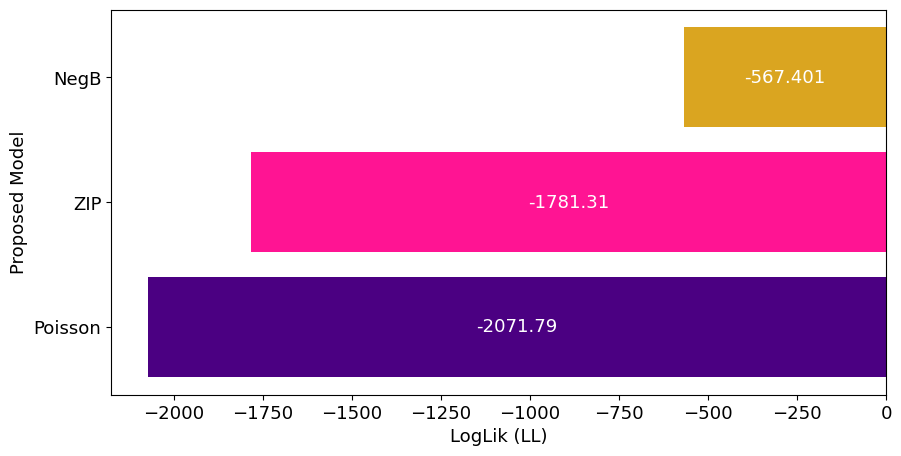

In [11]:
# Plotting the difference between Log-Likelihoods of Poisson and ZIP models

llf_df = pd.DataFrame({'model':['Poisson','ZIP','NegB'],
                      'loglik':[poisson_model.llf,
                                zip_model.llf,
                                neg_binomial_model.llf]})
fig, ax = plt.subplots(figsize=(10,5))
c = ['indigo', 'deeppink', 'goldenrod']
ax1 = ax.barh(llf_df.model,llf_df.loglik, color = c)
ax.bar_label(ax1, label_type='center', color='white', fontsize=13)
ax.set_ylabel("Proposed Model", fontsize=13)
ax.set_xlabel("LogLik (LL)", fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13)
plt.show()

In [12]:
# From the 3 models we've defined on the last 3 projects - Poisson, Negative Binomial and ZIP, it's obvious, from the
# LogLikelihood values above, that the classic NegB still wins, so far. We only have to define one more Count Data 
# model which is the Zero-Inflated Negative Binomial model, on the next project. And finally decide what model fits
# our data best, by simply checking the highest (less negative) LL.